# Pipeline de Detección de Anomalías en Contrataciones Públicas

Este notebook utiliza las funciones modulares definidas en `src/` 
para ejecutar el pipeline completo: carga de datos, limpieza, 
feature engineering y clustering.

In [8]:
import sys
import os

# Añade la raíz del proyecto al path para poder importar src/ como paquete
sys.path.insert(0, os.path.abspath('..'))

from src.logging_config import configurar_logging
configurar_logging()

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from src.data_loader import cargar_adjudicaciones
from src.preprocessing import limpiar_y_preparar
from src.clustering import aplicar_kmeans, aplicar_dbscan_muestra, calcular_eps_optimo
from src.config import FEATURES_COMPORTAMIENTO, RUTA_RESULTADOS

In [10]:
import sys
import os
sys.path.insert(0, os.path.abspath('..'))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from src.logging_config import configurar_logging
from src.data_loader import cargar_adjudicaciones
from src.preprocessing import limpiar_y_preparar
from src.clustering import aplicar_kmeans, aplicar_dbscan_muestra, calcular_eps_optimo, evaluar_clustering
from src.config import FEATURES_COMPORTAMIENTO, RUTA_RESULTADOS

configurar_logging()

In [11]:
df_total = cargar_adjudicaciones()
print(f"Dataset cargado: {df_total.shape[0]:,} registros | {df_total.shape[1]} columnas")
df_total.head(3)

16:28:31 | src.data_loader | INFO | Cargando datos 2022 desde: ../data/raw/CONOSCE_ADJUDICACIONES2022_0.xlsx
16:29:06 | src.data_loader | INFO | Cargando datos 2023 desde: ../data/raw/CONOSCE_ADJUDICACIONES2023_0.xlsx
16:29:37 | src.data_loader | INFO | Cargando datos 2024 desde: ../data/raw/CONOSCE_ADJUDICACIONES2024_0.xlsx
16:30:08 | src.data_loader | INFO | Cargando datos 2025 desde: ../data/raw/CONOSCE_ADJUDICACIONES2025_0.xlsx
16:30:37 | src.data_loader | INFO | Dataset unificado: 267772 registros, 26 columnas.


Dataset cargado: 267,772 registros | 26 columnas


,codigoentidad,entidad_ruc,entidad,tipoentidad,entidad_departamento,codigoconvocatoria,objetocontractual,tipoprocesoseleccion,proceso,descripcion_proceso,...,departamento_item,moneda,unidad_medida,ruc_proveedor,proveedor,tipo_proveedor,fecha_convocatoria,fecha_buenapro,fecha_consentimiento_bp,anio_fuente
0,1540,20171880115,MUNICIPALIDAD DISTRITAL DE TORATA,GOBIERNO LOCAL,MOQUEGUA,821389,Bien,Subasta Inversa Electrónica,SIE-SIE-30-2022-OEC/MDT-1,ADQUISICION DE BARRAS PARA CONSTUCCION PARA LA...,...,MOQUEGUA,Soles,Unidad,20449458436,COMERCIAL FERRETERIA FATIMA SOCIEDAD ANONIMA C...,Persona Juridica,01/07/2022,12/07/2022,20/07/2022,2022
1,1286,20162368614,MUNICIPALIDAD DISTRITAL DE SANTA ROSA - CHICLAYO,GOBIERNO LOCAL,LAMBAYEQUE,854888,Obra,Procedimiento Especial de Contratación,PEC-PROC-3-2022-MDSR/CS-1,"EJECUCION DE OBRA: ""REHABILITACION DE LOS COLE...",...,LAMBAYEQUE,Soles,Unidad,539347,CONSORCIO COLECTOR SANTA ROSA,Consorcio,18/10/2022,03/11/2022,03/11/2022,2022
2,1729,20191592990,MUNICIPALIDAD DISTRITAL DE YANAHUAYA,GOBIERNO LOCAL,PUNO,831616,Servicio,Adjudicación Simplificada,AS-SM-1-2022-MDY/CS-3,SERVICIO DE FABRICACION E INSTALACION DE TECHO...,...,PUNO,Soles,Servicio,20448362389,TECNICONS PERU E.I.R.L.,Persona Juridica,04/08/2022,18/08/2022,25/08/2022,2022


In [12]:
df_model, df_monto_cero = limpiar_y_preparar(df_total)

print(f"Dataset para clustering : {len(df_model):,} registros")
print(f"Registros monto ref = 0  : {len(df_monto_cero):,} registros")
df_model[FEATURES_COMPORTAMIENTO].describe().round(2)

16:30:38 | src.preprocessing | INFO | Registros iniciales: 267772
16:30:38 | src.preprocessing | INFO | Registros tras eliminar nulos: 267698 (eliminados: 74)
16:30:38 | src.preprocessing | INFO | Registros con monto referencial = 0 separados: 587
16:30:38 | src.preprocessing | INFO | Registros con diferencia_pct fuera del rango [-100%, 500%]: 66 (0.02%)
16:30:38 | src.preprocessing | INFO | Dataset final para clustering: 267111 registros.


Dataset para clustering : 267,111 registros
Registros monto ref = 0  : 587 registros


,diferencia_pct_cap,dias_proceso
count,267111.00,267111.00
mean,-7.74,31.93
std,19.06,51.59
min,-100.00,0.00
25%,-11.18,11.00
50%,-1.21,17.00
75%,0.00,35.00
max,500.00,1107.00


In [14]:
df_model, df_monto_cero = limpiar_y_preparar(df_total)
print(f"Datos procesados: {df_model.shape}")
print(f"Registros con monto cero separados: {len(df_monto_cero)}")

16:32:33 | src.preprocessing | INFO | Registros iniciales: 267772
16:32:34 | src.preprocessing | INFO | Registros tras eliminar nulos: 267698 (eliminados: 74)
16:32:34 | src.preprocessing | INFO | Registros con monto referencial = 0 separados: 587
16:32:34 | src.preprocessing | INFO | Registros con diferencia_pct fuera del rango [-100%, 500%]: 66 (0.02%)
16:32:35 | src.preprocessing | INFO | Dataset final para clustering: 267111 registros.


Datos procesados: (267111, 30)
Registros con monto cero separados: 587


In [17]:
metricas_kmeans = evaluar_clustering(X_scaled, df_model['cluster'].values)
print("=== Métricas K-Means (k=4) ===")
for nombre, valor in metricas_kmeans.items():
    print(f"  {nombre}: {valor}")

16:41:09 | src.clustering | INFO | Silhouette Score:       0.5601  (↑ mejor, máx=1)
16:41:09 | src.clustering | INFO | Davies-Bouldin Index:   0.6871  (↓ mejor, mín=0)
16:41:09 | src.clustering | INFO | Calinski-Harabasz:      138159.29  (↑ mejor)


=== Métricas K-Means (k=4) ===
  silhouette_score: 0.5601
  davies_bouldin_index: 0.6871
  calinski_harabasz_score: 138159.29


In [16]:
df_model, X_scaled, scaler = aplicar_kmeans(df_model, columnas=FEATURES_COMPORTAMIENTO)

resumen = (
    df_model.groupby("cluster")[FEATURES_COMPORTAMIENTO]
    .mean()
    .round(1)
    .assign(n_registros=df_model.groupby("cluster").size())
    .assign(pct=lambda x: (x["n_registros"] / len(df_model) * 100).round(1))
)
print(resumen)

         diferencia_pct_cap  dias_proceso  n_registros   pct
cluster                                                     
0                      -2.4          24.5       217671  81.5
1                     -33.5          37.8        44765  16.8
2                     -26.0         330.4         4507   1.7
3                     369.8          51.3          168   0.1


In [ ]:
# Primero calcula el eps óptimo (revisa el log para elegir el valor)
calcular_eps_optimo(X_scaled)

# Luego aplica DBSCAN
muestra_idx, clusters_dbscan = aplicar_dbscan_muestra(X_scaled)

15:42:30 | src.clustering | INFO | Distancias al 10-ésimo vecino (percentiles):
15:42:30 | src.clustering | INFO |   P50: 0.0236
15:42:30 | src.clustering | INFO |   P75: 0.0616
15:42:30 | src.clustering | INFO |   P90: 0.1591
15:42:30 | src.clustering | INFO |   P95: 0.3077
15:42:30 | src.clustering | INFO |   P99: 1.0425
15:42:30 | src.clustering | INFO |   Sugerencia: usa el valor donde la curva 'coda' como eps.
15:42:30 | src.clustering | INFO | Aplicando DBSCAN: eps=0.50, min_samples=10, muestra=10000/267111 registros.
15:42:31 | src.clustering | INFO | DBSCAN: 2 clusters encontrados, 129 puntos de ruido (1.3%).


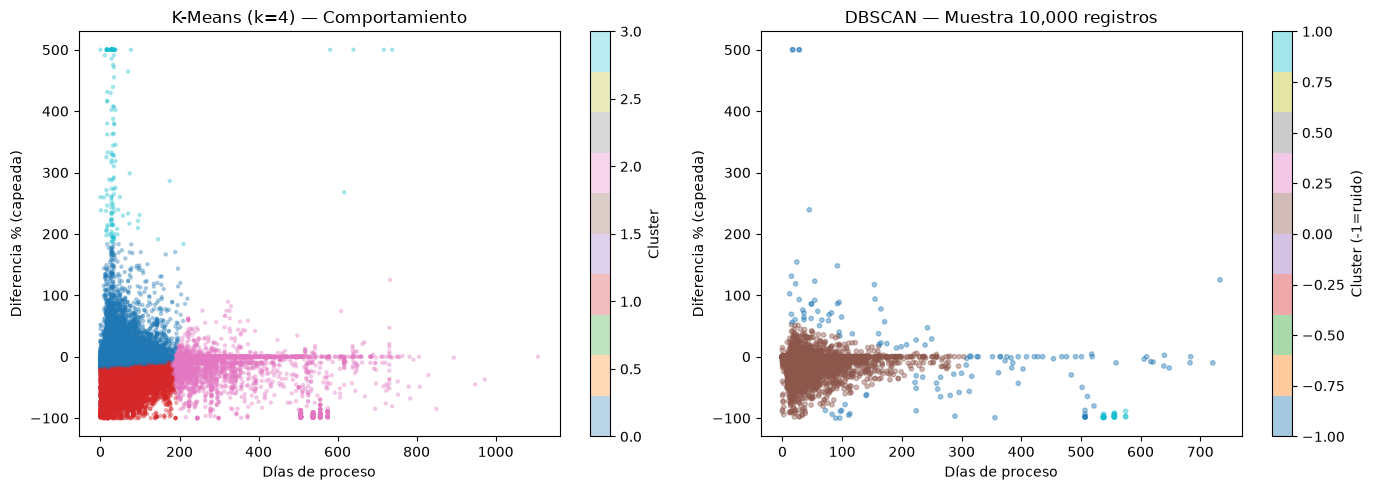

Gráfico guardado.


In [ ]:
import os

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# K-Means
scatter = axes[0].scatter(
    df_model["dias_proceso"],
    df_model["diferencia_pct_cap"],
    c=df_model["cluster"],
    cmap="tab10", alpha=0.3, s=5
)
axes[0].set_title("K-Means (k=4) — Comportamiento")
axes[0].set_xlabel("Días de proceso")
axes[0].set_ylabel("Diferencia % (capeada)")
plt.colorbar(scatter, ax=axes[0], label="Cluster")

# DBSCAN
df_muestra = df_model.iloc[muestra_idx].copy()
df_muestra["cluster_dbscan"] = clusters_dbscan
scatter2 = axes[1].scatter(
    df_muestra["dias_proceso"],
    df_muestra["diferencia_pct_cap"],
    c=df_muestra["cluster_dbscan"],
    cmap="tab10", alpha=0.4, s=10
)
axes[1].set_title("DBSCAN — Muestra 10,000 registros")
axes[1].set_xlabel("Días de proceso")
axes[1].set_ylabel("Diferencia % (capeada)")
plt.colorbar(scatter2, ax=axes[1], label="Cluster (-1=ruido)")

plt.tight_layout()
os.makedirs(RUTA_RESULTADOS, exist_ok=True)
plt.savefig(f"{RUTA_RESULTADOS}resumen_clusters.png", dpi=150)
plt.show()
print("Gráfico guardado.")

In [ ]:
# Cluster 3 = sobrecosto extremo, filtrar monto ref > 1000 soles
casos_sospechosos = df_model[
    (df_model["cluster"] == 3) &
    (df_model["monto_referencial_item_soles"] > 1000)
].copy()

casos_sospechosos = casos_sospechosos.sort_values(
    "diferencia_pct_cap", ascending=False
)

casos_sospechosos.to_csv(f"{RUTA_RESULTADOS}casos_sospechosos.csv", index=False)
print(f"Casos sospechosos exportados: {len(casos_sospechosos):,} registros")
casos_sospechosos.head(10)

Casos sospechosos exportados: 67 registros


,codigoentidad,entidad_ruc,entidad,tipoentidad,entidad_departamento,codigoconvocatoria,objetocontractual,tipoprocesoseleccion,proceso,descripcion_proceso,...,tipo_proveedor,fecha_convocatoria,fecha_buenapro,fecha_consentimiento_bp,anio_fuente,diferencia_monto,diferencia_pct,diferencia_pct_cap,dias_proceso,cluster
142418,326,20156959783,MUNICIPALIDAD PROVINCIAL DE ANDAHUAYLAS,GOBIERNO LOCAL,APURIMAC,997672,Bien,Subasta Inversa Electrónica,SIE-SIE-4-2024-MP-A-1,CONTRATACION DE BIENES PARA LA ADQUISICION DE ...,...,Persona Natural,2024-03-20,2024-04-22,02/05/2024,2024,373767.17,560.094889,500.000000,33,3
61306,10536,20199189710,GOBIERNO REGIONAL DE MADRE DE DIOS-DIRECCION R...,GOBIERNO REGIONAL,MADRE DE DIOS,846656,Servicio,Adjudicación Simplificada,AS-SM-7-2022-DRTC-MDD/OEC-1,SERVICIO DE MANTENIMIENTO RUTINARIO DEL CAMINO...,...,Persona Natural,2022-09-23,2022-10-11,20/10/2022,2022,2723280.00,2504.856512,500.000000,18,3
64626,2433,20100128218,PETROLEOS DEL PERU S.A.,PETROPERU,LIMA,790418,Bien,Adjudicación Selectiva,SEL-PROC-8-2022-OFP / PETROPERU-1,ADQUISICIÓN DE EQUIPOS DE PROTECCIÓN PERSONAL ...,...,Persona Juridica,2022-03-28,2022-04-29,10/05/2022,2022,1969978.43,11342.855851,500.000000,32,3
244314,1018,20198440052,MUNICIPALIDAD DISTRITAL DE JACAS CHICO,GOBIERNO LOCAL,HUANUCO,1115784,Servicio,Concurso Público Abreviado Séptima DCF Ley N°3...,CP 7ma DCF Ley N°32069-ABR-1-2025-MDJCH/CS-1-1,CONTRATACIÓN DE SERVICIO PARA LA EJECUCION DE ...,...,Persona Juridica,2025-04-30,2025-06-06,09/06/2025,2025,1436905.57,2234.945664,500.000000,37,3
238146,2362,20163947693,EMPRESA MUNICIPAL DE SANEAMIENTO BASICO DE PUN...,GOBIERNO LOCAL,PUNO,1150629,Bien,Licitación Pública Abreviada,LP-ABR-7-2025-EMSAPUNO S.A.-1,"ADQUISICION DE TABLEROS DE CONTROL, PARA EL PR...",...,Persona Juridica,2025-08-26,2025-10-01,10/10/2025,2025,394960.00,897.636364,500.000000,36,3
214865,200013,20479393568,UNIVERSIDAD NACIONAL TORIBIO RODRIGUEZ DE MEND...,GOBIERNO NACIONAL,AMAZONAS,1150807,Bien,Convenio,CONV-PROC-27-2025-UNTRN/CE-1,ADQUISICIÓN DE MATERIALES Y REACTIVOS PARA CUL...,...,Persona Juridica,2025-09-11,2025-10-15,15/10/2025,2025,13588.32,905.888000,500.000000,34,3
189177,2433,20100128218,PETROLEOS DEL PERU S.A.,PETROPERU,LIMA,1060999,Bien,Adjudicación Abreviada,ABR-PROC-50-2024-OTL / PETROPERU-1,ADQUISICIÓN DE SELLOS MECÁNICOS JOHN CRANE PAR...,...,Persona Juridica,2024-10-15,2024-10-15,16/10/2024,2024,16110000.00,903.176072,500.000000,0,3
244547,1637,20179834317,MUNICIPALIDAD DISTRITAL DE EL ALTO,GOBIERNO LOCAL,PIURA,1099323,Bien,Subasta Inversa Electrónica,SIE-SIE-1-2025-OEC-MDEA-2,ADQUISICION DE COMBUSTIBLE DIESEL BS S-50 PARA...,...,Persona Juridica,2025-03-21,2025-04-01,09/04/2025,2025,310073.22,490.880206,490.880206,11,3
267505,200013,20479393568,UNIVERSIDAD NACIONAL TORIBIO RODRIGUEZ DE MEND...,GOBIERNO NACIONAL,AMAZONAS,1124984,Bien,Convenio,CONV-PROC-18-2025-UNTRM/PROCIENCI-1,Adquisición de reactivos e insumos de laborato...,...,Persona Juridica,2025-06-16,2025-07-18,31/07/2025,2025,10932.00,475.304348,475.304348,32,3
179005,34,20498390570,GOBIERNO REGIONAL DE AREQUIPA Sede Central,GOBIERNO REGIONAL,AREQUIPA,1040638,Servicio,Adjudicación Simplificada,AS-SM-175-2024-GRA-1,CONTRATACION DEL SERVICIO DE INSTALACION DE CO...,...,Persona Juridica,2024-08-08,2024-10-17,25/10/2024,2024,245060.00,464.568720,464.568720,70,3
